# Test Performance Analysis
In this notebook, we analyze the performance of the selected models on the test dataset and account for trading costs on rebalancing.

### Setup

In [42]:
# All imports
import sys
from pathlib import Path

# Get the absolute path of the directory one level up
root_dir = Path.cwd().parent

# Add it to sys.path if it's not already there
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import os
import numpy as np
import pandas as pd

from scipy import stats
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import plotly.graph_objects as go
from src.utils.io import load_path_config, load_json
from src.data_processing.loading import load_single_csv
from src.utils.constants import EQ_WT_NAME, SP500_NAME
from src.utils.formatting import deserialize_np_dict
from src.evaluation.evaluator import Evaluator
from src.evaluation.selection import pareto_dominance, high_corr_with_each_metric
from src.visualization.plots import plot_3d_pareto, plot_corr, plot_2d_pareto

from src.evaluation.metrics import MetricLibrary
from src.models.registry import NNModelLibrary, TradModelLibrary

In [43]:
paths_config = load_path_config(os.path.join('../config', 'paths.json'))

# Convert str paths to Path
artifacts_paths = {}
for name, path in paths_config['artifacts'].items():
    dir_path = Path('../'+ path)
    artifacts_paths[name] = dir_path

TradModelLibrary.autodiscover('src.models')
# Registering all NN models to the library
NNModelLibrary.autodiscover('src.models') # MUST be executed for model registration

#### Average Portfolio Performances
This is the average of portfolio metrics over all windows of walk steps. It is not the performances of the models over the entire test period of 2 years.

In [44]:
NUM_SEEDS = 30

test_avg_perf = load_single_csv(
    artifacts_paths['test_perf_dir'] / f'avg_test_perf_all_{NUM_SEEDS}_seeds.csv',
    index_dt=False
)

# Daily returns for all models at all steps
test_returns = load_json(artifacts_paths['test_perf_dir'] / 'test_returns_all.json')

test_avg_perf

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
AttentionLSTM-custom_loss_11,0.010920,0.015033,0.031018,-0.095764,-0.027043,1.056010,0.006095
DeformTime-custom_loss_11,0.009839,0.009608,0.041562,-0.185795,-0.052227,1.079436,0.008913
Equal_Weight,-0.011262,-0.009038,-0.001388,-0.095187,-0.022625,0.993425,0.002025
GlobalMinimumVariance,-0.010738,-0.024800,-0.028788,-0.084675,-0.019662,0.958025,-0.000988
HierarchialRiskParity,-0.008913,-0.010000,-0.004387,-0.087700,-0.020313,0.991587,0.001150
InvertedAttentionLSTM-custom_loss_10,-0.015445,-0.007775,-0.003881,-0.114444,-0.028651,0.999257,0.002041
MeanVariancePortfolio,-0.047062,-0.043537,-0.071163,-0.156463,-0.034100,0.919462,-0.002475
NaiveMVP,-0.010738,-0.024775,-0.028800,-0.084675,-0.019662,0.958037,-0.000988
NestedClusteredOptimization,-0.000188,-0.004712,-0.011388,-0.081687,-0.020000,1.002263,0.000025
PatchTST-custom_loss_11,-0.005257,-0.005822,-0.002209,-0.106029,-0.027897,1.006269,0.003751


### Overall Performance Analysis
Analysis of model average performances on the test set across multiple seeds.

<Axes: title={'center': 'Mean Sharpe (Over All Seeds) vs Portfolio Optimizer'}>

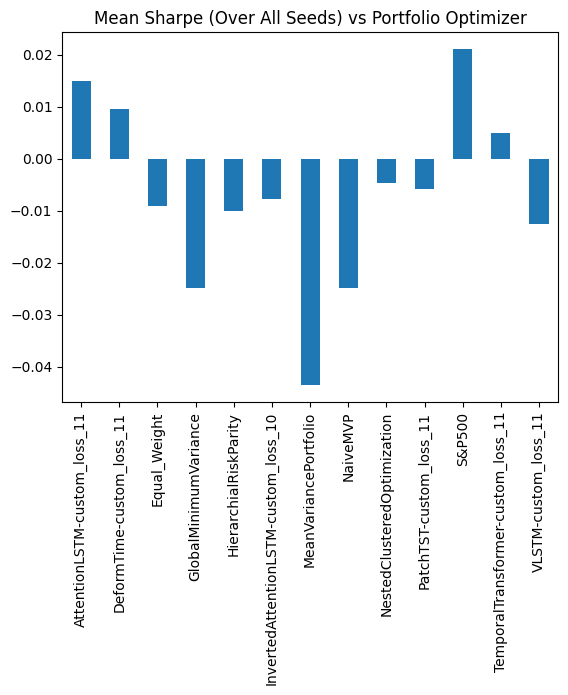

In [45]:
test_avg_perf['sharpe'].plot.bar(title='Mean Sharpe (Over All Seeds) vs Portfolio Optimizer')

<Axes: title={'center': 'Mean CVaR (Over All Seeds) vs Portfolio Optimizer'}>

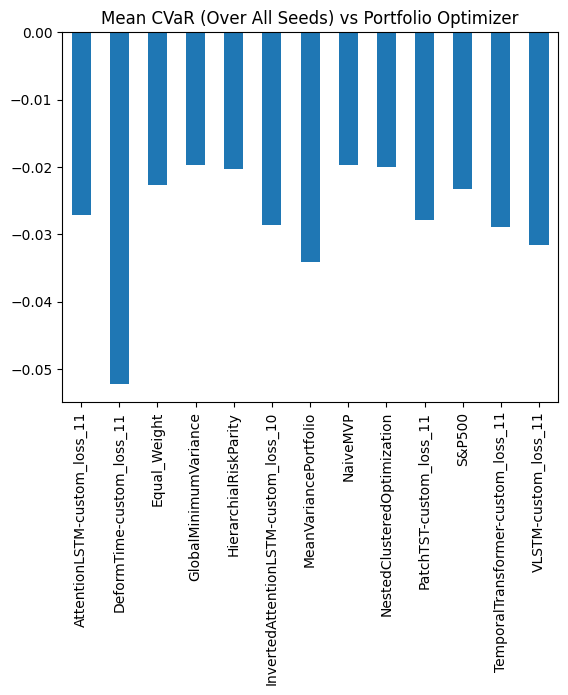

In [46]:
test_avg_perf['cvar'].plot.bar(title='Mean CVaR (Over All Seeds) vs Portfolio Optimizer')

<Axes: title={'center': 'Mean Compounded Returns (Over All Seeds) vs Portfolio Optimizer'}>

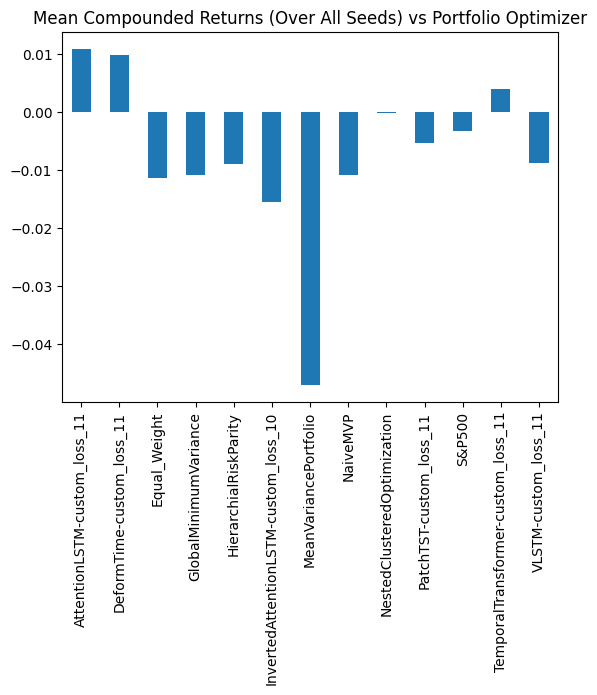

In [47]:
test_avg_perf['compunded_return'].plot.bar(title='Mean Compounded Returns (Over All Seeds) vs Portfolio Optimizer')

#### Models Portfolio Performances
This is the performance of each portfolio for the entire validation period

#### Calculating Multi-Seed Statistics

In [48]:
# Deserialize dict: replace lists with np.array()
test_returns_deserial = deserialize_np_dict(test_returns)

# Separate NN and benchmarks
all_benches = TradModelLibrary.list_models()
all_benches.extend([EQ_WT_NAME, SP500_NAME])

nn_seed_rets = test_returns_deserial['nn_models']
bench_rets = test_returns_deserial['benchmarks']

In [49]:
# Remove date range keys for nn returns, We also collect model+loss names
nn_model_losses = []
nn_seed_rets_no_dates = {seed: {} for seed in nn_seed_rets.keys()}
for seed, seed_perfs in nn_seed_rets.items():
    for modl_name, windows_dict in seed_perfs.items():
        nn_model_losses.append(modl_name)
        nn_seed_rets_no_dates[seed][modl_name] = np.stack(
            [wind_rets for dates, wind_rets in windows_dict.items()]
        )

nn_model_losses = set(nn_model_losses)

# Remove date range keys for benchmarks
bench_rets_no_dates = {name: {} for name in bench_rets.keys()}
for modl_name, windows_dict in bench_rets.items():
        bench_rets_no_dates[modl_name] = np.stack(
            [wind_rets for dates, wind_rets in windows_dict.items()]
        )

Calculate Lower Confidence Bound for all models over all seeds (better estimate of overall performance).

In [50]:
# Calculate Statistics for Neural networks (across all seeds)

seed_metric_dfs = []
for seed, seed_perfs in nn_seed_rets_no_dates.items():
    evaluator = Evaluator(
        eval_returns=None,
        ba_eval=None,
        all_daily_returns=seed_perfs,
        metrics_lib=MetricLibrary.items()
    )
    seed_metric_dfs.append(evaluator.calc_pf_performances())

all_seed_perf = pd.concat(seed_metric_dfs)
# Stats Calculation
n = all_seed_perf.groupby(level=0).count()
avg_perf_metrics = all_seed_perf.groupby(level=0).mean() # Average over seeds
std_perf_metrics = all_seed_perf.groupby(level=0).std(ddof=1) # Std across seeds

# Extract the common n (assuming all models have same count)
n_seeds = n.iloc[0, 0]   # or n['sharpe'].iloc[0] if column exists

# Critical t-value for one‑sided 95% confidence
t_val = stats.t.ppf(0.95, df=n_seeds-1)

lower_bound_df = avg_perf_metrics - t_val * (std_perf_metrics / np.sqrt(n_seeds))

In [51]:
# Calculate performance of benchmark portfolios (no seeds)

evaluator = Evaluator(
    eval_returns=None,
    ba_eval=None,
    all_daily_returns=bench_rets_no_dates, # Deserialize dict: replace lists with np.array()
    metrics_lib=MetricLibrary.items()
)

bench_perfs = evaluator.calc_pf_performances()

Adding benchmarks and tradional models to the above average and lower bound dataframes. We do not need to calculate lower bound for the benchmarks/tradional models because they were not run for multiple seeds. Hence, consider the mean metrics over all windows as their overall performance.


In [52]:
avg_perf_metrics = pd.concat(
    [avg_perf_metrics, bench_perfs],
    axis=0
)
avg_perf_metrics = avg_perf_metrics.sort_values(by='sharpe', ascending=False)
print('AVERAGE PERFORMANCE OF NEURAL NETWORKS ACROSS ALL SEEDS:')
avg_perf_metrics

AVERAGE PERFORMANCE OF NEURAL NETWORKS ACROSS ALL SEEDS:


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
AttentionLSTM-custom_loss_11,0.078567,0.018263,0.028960,-0.202073,-0.028573,1.050447,0.00135
DeformTime-custom_loss_11,0.026123,0.010540,0.016597,-0.461393,-0.057627,1.032857,0.00091
TemporalTransformer-custom_loss_11,0.020713,0.009450,0.015693,-0.235910,-0.030247,1.026030,0.00077
NestedClusteredOptimization,-0.006400,0.003400,0.005200,-0.172000,-0.021500,1.008900,0.00020
S&P500,-0.045200,-0.001500,-0.002300,-0.254300,-0.028400,0.996000,-0.00010
PatchTST-custom_loss_11,-0.059590,-0.002887,-0.004487,-0.234550,-0.029393,0.992837,-0.00015
VLSTM-custom_loss_11,-0.087210,-0.004757,-0.007417,-0.300157,-0.032947,0.988190,-0.00020
HierarchialRiskParity,-0.079400,-0.011200,-0.017800,-0.198000,-0.022400,0.971400,-0.00060
Equal_Weight,-0.099900,-0.012600,-0.020200,-0.212300,-0.025500,0.967800,-0.00070
InvertedAttentionLSTM-custom_loss_10,-0.132253,-0.013000,-0.020817,-0.275113,-0.031743,0.967173,-0.00062


In [53]:
lower_bound_df = pd.concat(
    [lower_bound_df, bench_perfs],
    axis=0
)
lower_bound_df = lower_bound_df.sort_values(by='sharpe', ascending=False)
print('LOWER CONFIDENCE BOUND (95%) PERFORMANCE OF NEURAL NETWORKS ACROSS ALL SEEDS:')
lower_bound_df

LOWER CONFIDENCE BOUND (95%) PERFORMANCE OF NEURAL NETWORKS ACROSS ALL SEEDS:


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
AttentionLSTM-custom_loss_11,0.052865,0.014512,0.023107,-0.215020,-0.029281,1.039968,0.001047
TemporalTransformer-custom_loss_11,-0.013372,0.004586,0.008261,-0.253991,-0.030897,1.012535,0.000412
NestedClusteredOptimization,-0.006400,0.003400,0.005200,-0.172000,-0.021500,1.008900,0.000200
DeformTime-custom_loss_11,-0.092251,0.001531,0.002658,-0.495823,-0.059385,1.007027,0.000336
S&P500,-0.045200,-0.001500,-0.002300,-0.254300,-0.028400,0.996000,-0.000100
PatchTST-custom_loss_11,-0.079268,-0.006079,-0.009436,-0.240397,-0.029859,0.984546,-0.000333
VLSTM-custom_loss_11,-0.115722,-0.008778,-0.013685,-0.312783,-0.033604,0.977668,-0.000417
HierarchialRiskParity,-0.079400,-0.011200,-0.017800,-0.198000,-0.022400,0.971400,-0.000600
Equal_Weight,-0.099900,-0.012600,-0.020200,-0.212300,-0.025500,0.967800,-0.000700
NaiveMVP,-0.090200,-0.016200,-0.024700,-0.168400,-0.021000,0.958700,-0.000900


In [54]:
print('STANDARD DEVIATION OF PERFORMANCE OF NEURAL NETWORKS ACROSS ALL SEEDS:')
std_perf_metrics

STANDARD DEVIATION OF PERFORMANCE OF NEURAL NETWORKS ACROSS ALL SEEDS:


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
AttentionLSTM-custom_loss_11,0.082850,0.012093,0.018867,0.041734,0.002280,0.033780,0.000977
DeformTime-custom_loss_11,0.381586,0.029040,0.044931,0.110987,0.005668,0.083264,0.001849
InvertedAttentionLSTM-custom_loss_10,0.080134,0.012693,0.020449,0.046518,0.001370,0.032014,0.000650
PatchTST-custom_loss_11,0.063432,0.010292,0.015956,0.018848,0.001503,0.026726,0.000590
TemporalTransformer-custom_loss_11,0.109875,0.015679,0.023960,0.058284,0.002096,0.043500,0.001155
VLSTM-custom_loss_11,0.091910,0.012963,0.020205,0.040703,0.002118,0.033919,0.000701


#### Lower Confidence Bound Metrics Pareto Frontier Analysis

Pareto Frontier for all metrics

In [55]:
temp_lcb = lower_bound_df.copy()

temp_lcb['dominated'] = pareto_dominance(temp_lcb, list(temp_lcb.columns))

frontier_3d = temp_lcb[~temp_lcb['dominated']]
frontier_3d

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar,dominated
AttentionLSTM-custom_loss_11,0.052865,0.014512,0.023107,-0.21502,-0.029281,1.039968,0.001047,False
NestedClusteredOptimization,-0.006400,0.003400,0.005200,-0.17200,-0.021500,1.008900,0.000200,False
NaiveMVP,-0.090200,-0.016200,-0.024700,-0.16840,-0.021000,0.958700,-0.000900,False
GlobalMinimumVariance,-0.090200,-0.016200,-0.024700,-0.16840,-0.021000,0.958700,-0.000900,False


Metric Correlation Analysis and 3D Pareto Frontier

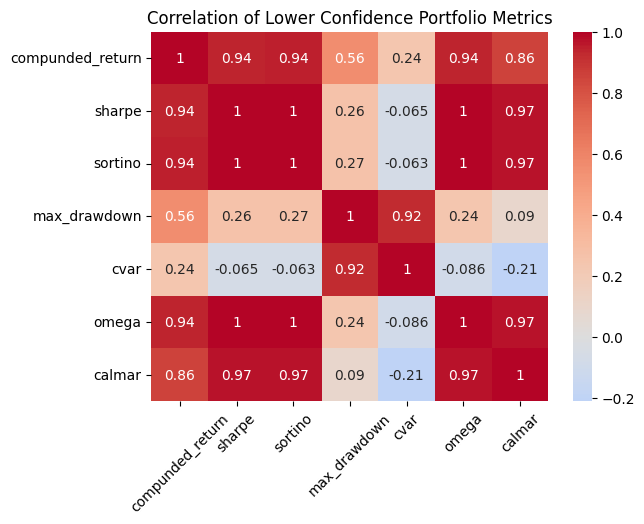


compunded_return is highly correlated with:
  sharpe: 0.942
  sortino: 0.944
  omega: 0.935
  calmar: 0.855

sharpe is highly correlated with:
  compunded_return: 0.942
  sortino: 1.000
  omega: 1.000
  calmar: 0.968

sortino is highly correlated with:
  compunded_return: 0.944
  sharpe: 1.000
  omega: 0.999
  calmar: 0.968

max_drawdown is highly correlated with:
  cvar: 0.924

cvar is highly correlated with:
  max_drawdown: 0.924

omega is highly correlated with:
  compunded_return: 0.935
  sharpe: 1.000
  sortino: 0.999
  calmar: 0.974

calmar is highly correlated with:
  compunded_return: 0.855
  sharpe: 0.968
  sortino: 0.968
  omega: 0.974


In [56]:
corr = lower_bound_df.corr()

plot_corr(corr, title='Correlation of Lower Confidence Portfolio Metrics')
high_corr_with_each_metric(corr, threshold=0.75)

In [57]:
temp_lcb = lower_bound_df.copy()
cols = ['sharpe', 'compunded_return', 'cvar']
temp_lcb['dominated_3d'] = pareto_dominance(temp_lcb, cols)

frontier_3d = temp_lcb[~temp_lcb['dominated_3d']]
fig = plot_3d_pareto(
    df=temp_lcb,
    x_col='sharpe',
    y_col='compunded_return',
    z_col='cvar',
    dominated_col='dominated_3d',
    title='3D Pareto Frontier Lower Confidence Bound (Sharpe, Compounded Return, CVaR)',
    x_title='Sharpe Ratio',
    y_title='Compounded Return',
    z_title='CVaR (higher better)'
)

fig.show()
frontier_3d

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar,dominated_3d
AttentionLSTM-custom_loss_11,0.052865,0.014512,0.023107,-0.21502,-0.029281,1.039968,0.001047,False
NestedClusteredOptimization,-0.006400,0.003400,0.005200,-0.17200,-0.021500,1.008900,0.000200,False
NaiveMVP,-0.090200,-0.016200,-0.024700,-0.16840,-0.021000,0.958700,-0.000900,False
GlobalMinimumVariance,-0.090200,-0.016200,-0.024700,-0.16840,-0.021000,0.958700,-0.000900,False


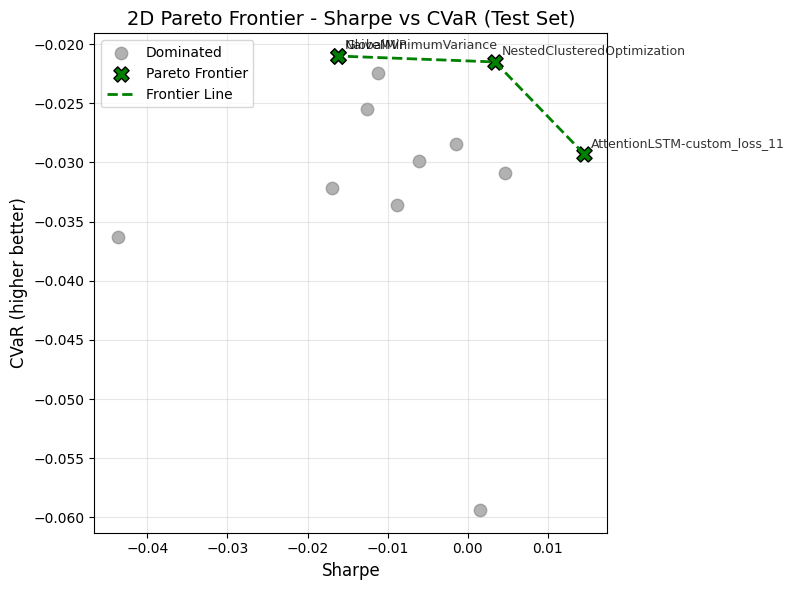

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar,dominated
AttentionLSTM-custom_loss_11,0.052865,0.014512,0.023107,-0.21502,-0.029281,1.039968,0.001047,False
NestedClusteredOptimization,-0.006400,0.003400,0.005200,-0.17200,-0.021500,1.008900,0.000200,False
NaiveMVP,-0.090200,-0.016200,-0.024700,-0.16840,-0.021000,0.958700,-0.000900,False
GlobalMinimumVariance,-0.090200,-0.016200,-0.024700,-0.16840,-0.021000,0.958700,-0.000900,False


In [58]:
temp_perf = lower_bound_df.copy()

temp_perf['dominated'] = pareto_dominance(temp_perf, ['sharpe', 'cvar'])

frontier_2d = temp_perf[~temp_perf['dominated']]

fig = plot_2d_pareto(
    df=temp_perf,
    x_col='sharpe',
    y_col='cvar',
    dominated_col='dominated',
    title='2D Pareto Frontier - Sharpe vs CVaR (Test Set)',
    xlabel='Sharpe',
    ylabel='CVaR (higher better)'
)
plt.show()
frontier_sorted = frontier_2d.sort_values('sharpe', ascending=False)
frontier_sorted

### Statistical Significance
From the correlation of mean of metrics (and even lower confidence bound), use Sharpe, CVaR as our main metrics and we can use Coumpounded returns too. Then we check their normality

In [59]:
from src.visualization.plots import plot_qq_by_model, plot_hist_by_model

Historgrams for Model+Loss Combos, for Selected Metrics


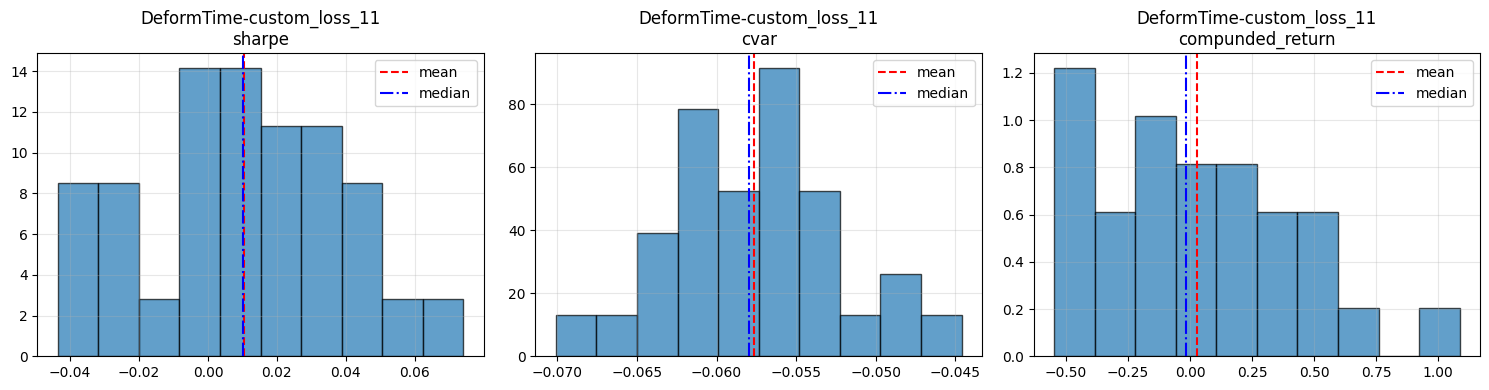

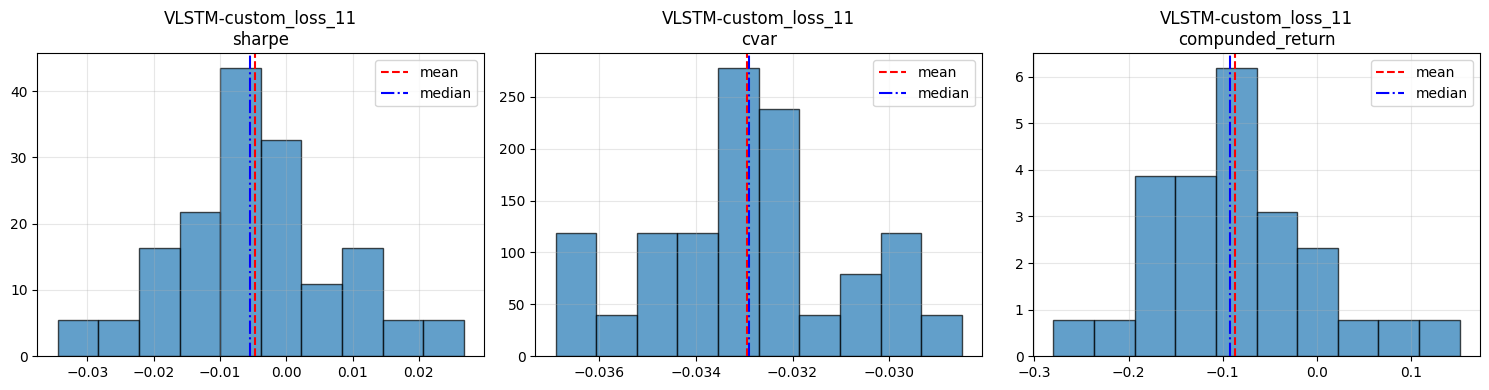

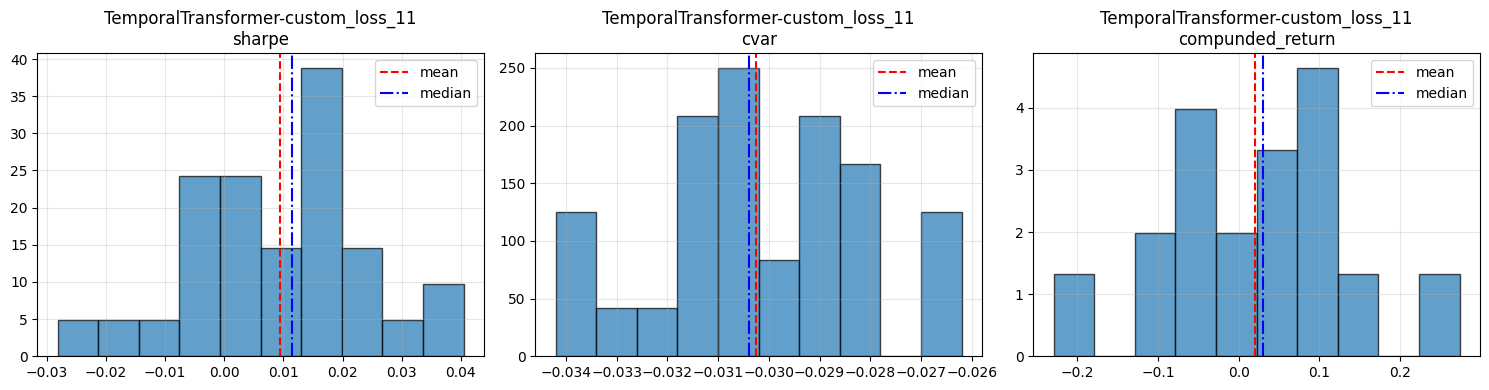

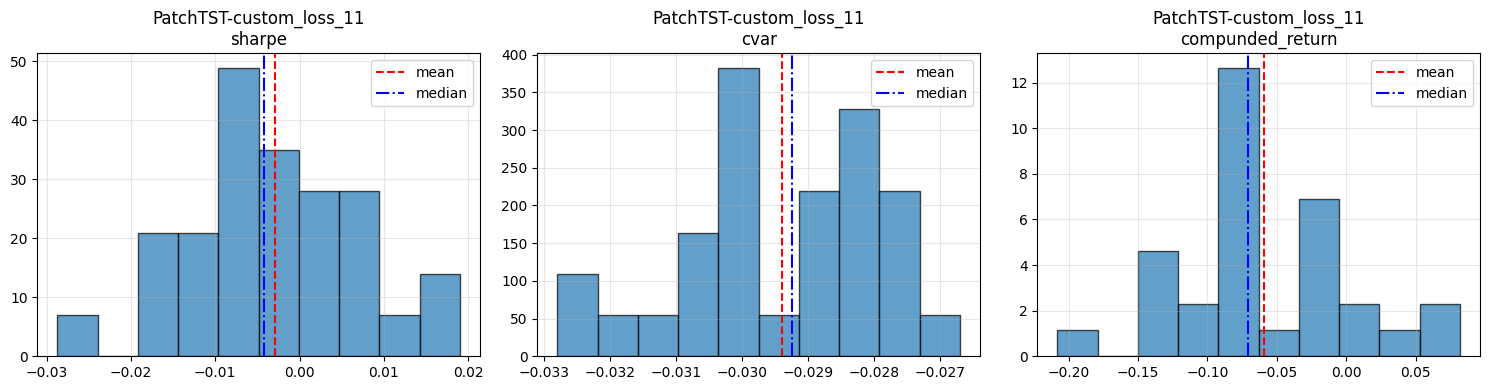

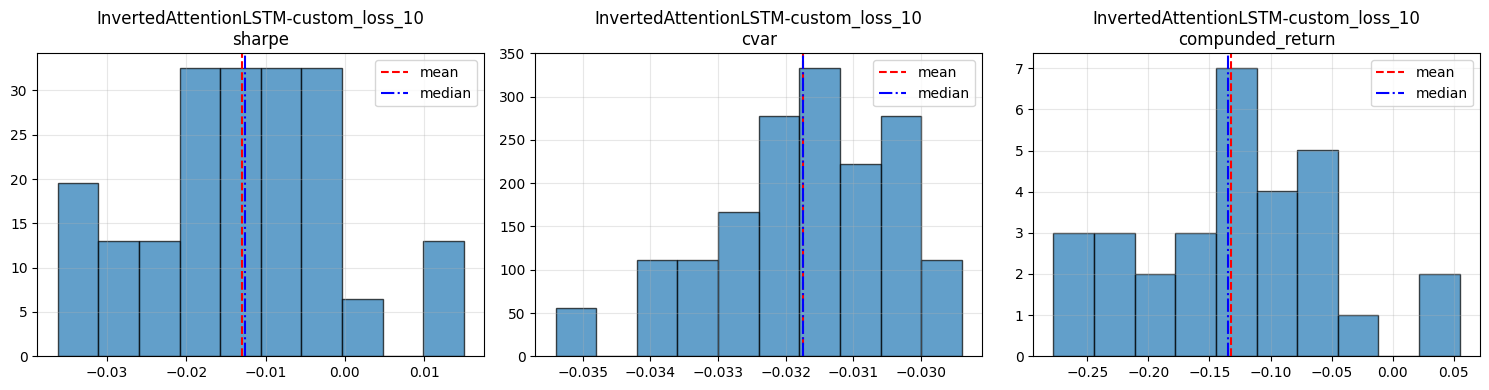

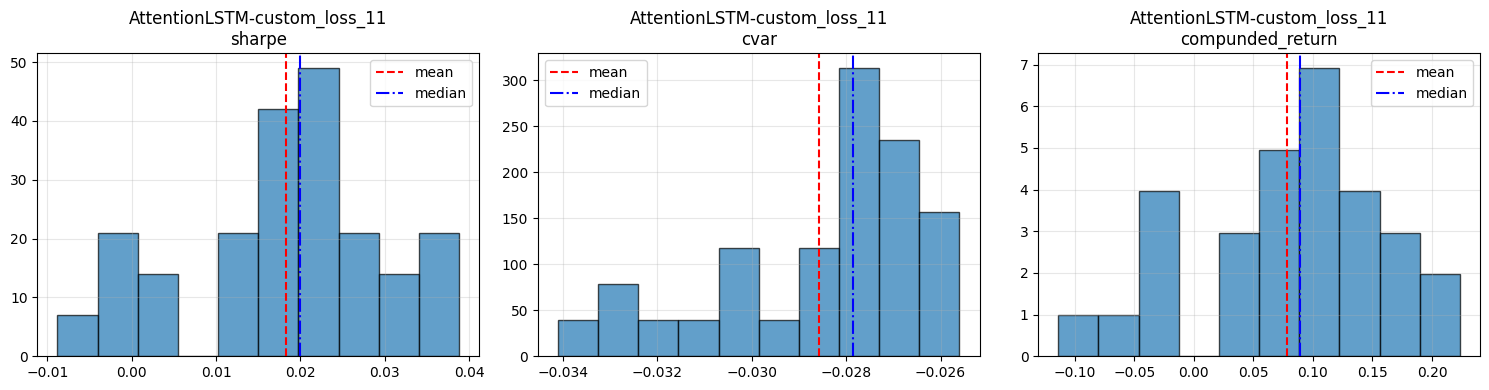

In [60]:
metrics_for_tests = ['sharpe', 'cvar', 'compunded_return']
# Historgrams
print('Historgrams for Model+Loss Combos, for Selected Metrics')
plot_hist_by_model(all_seed_perf, nn_model_losses, metrics_for_tests, bins=10)

Q-Q Plots for Model+Loss Combos, for Selected Metrics


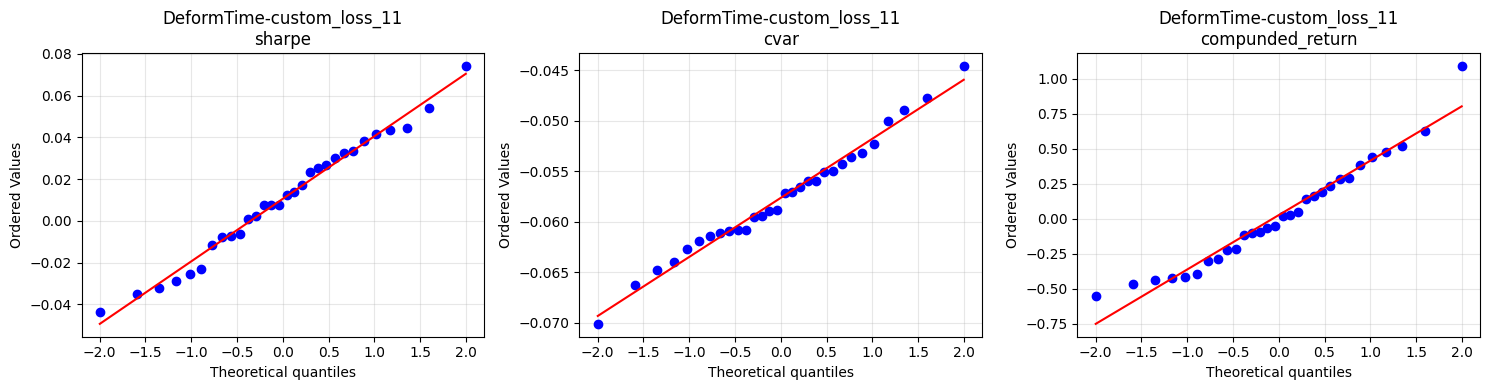

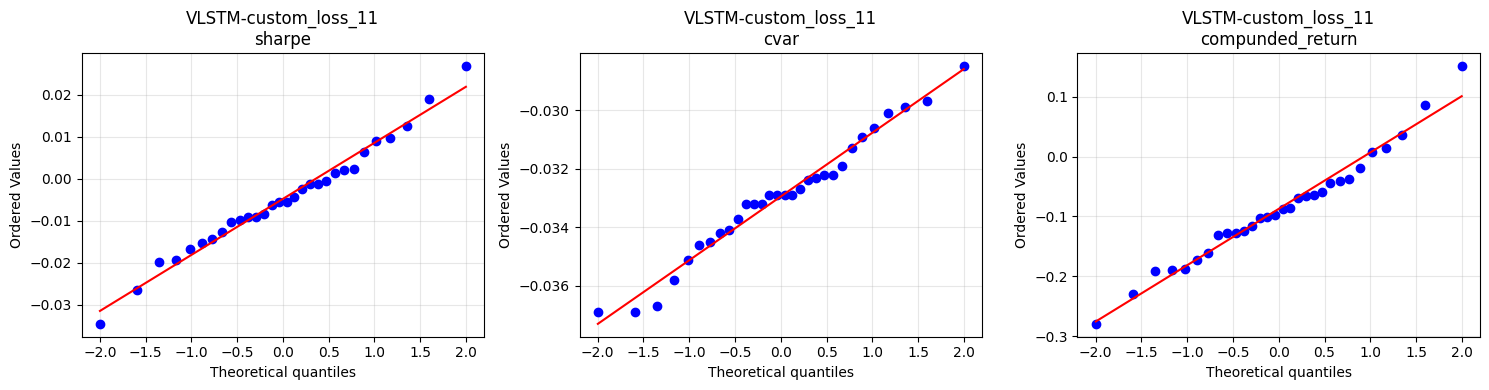

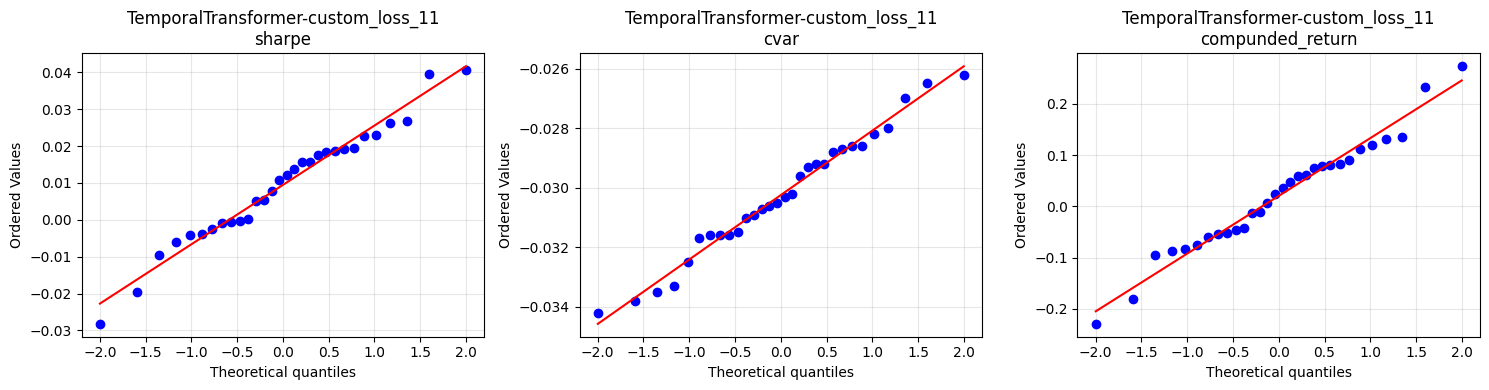

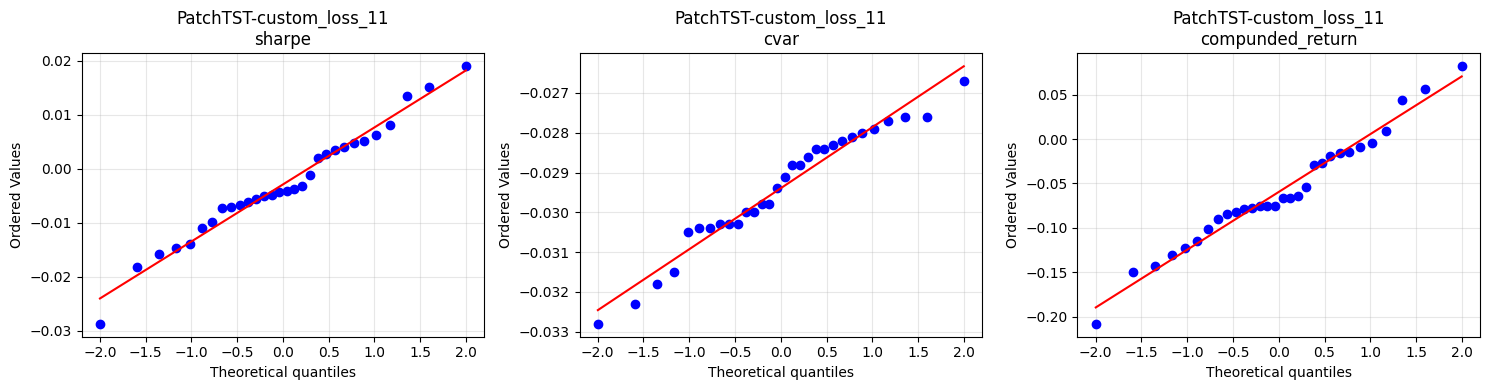

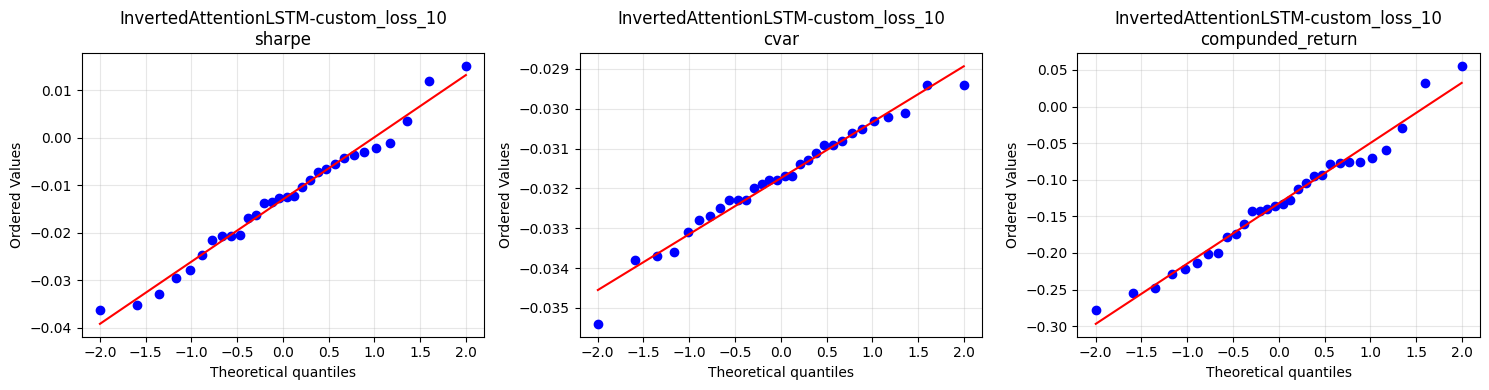

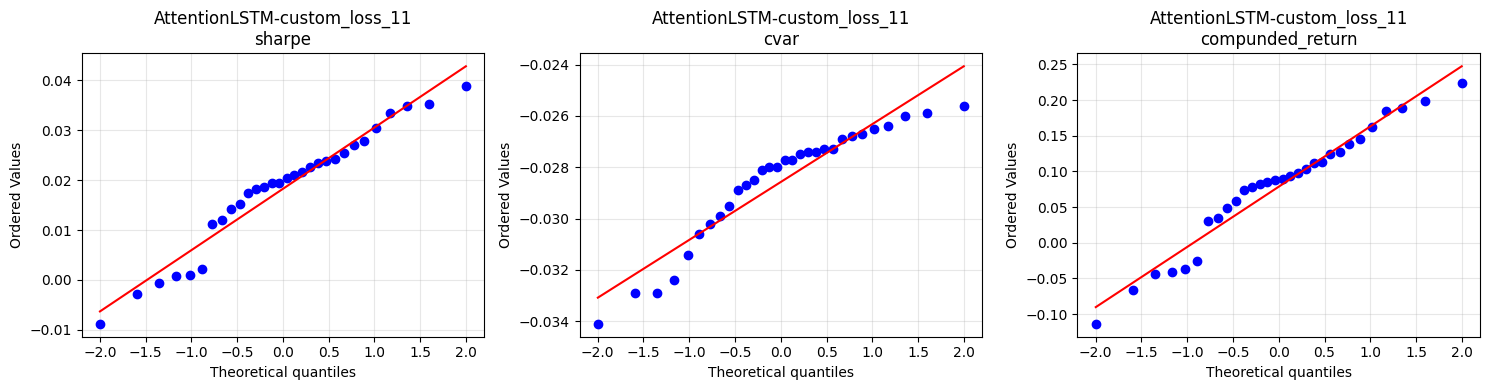

In [61]:
# Q-Q Plots
print('Q-Q Plots for Model+Loss Combos, for Selected Metrics')
plot_qq_by_model(all_seed_perf, nn_model_losses, metrics_for_tests)

##### Shapiro-Wilk Test for normality

In [62]:
from src.evaluation.post_hoc import test_normality_by_model

In [63]:
normality_table = test_normality_by_model(
    all_seed_perf, nn_model_losses, metrics_for_tests
)
normality_table

,model_loss,metric,statistic,p_value_raw,normality_assumed,p_value_corrected
0,DeformTime-custom_loss_11,sharpe,0.983452,0.908001,True,1.000000
1,DeformTime-custom_loss_11,cvar,0.989942,0.990815,True,1.000000
2,DeformTime-custom_loss_11,compunded_return,0.958634,0.285723,True,1.000000
3,VLSTM-custom_loss_11,sharpe,0.989454,0.988090,True,1.000000
4,VLSTM-custom_loss_11,cvar,0.973604,0.641693,True,1.000000
5,VLSTM-custom_loss_11,compunded_return,0.982285,0.882501,True,1.000000
6,TemporalTransformer-custom_loss_11,sharpe,0.978178,0.775313,True,1.000000
7,TemporalTransformer-custom_loss_11,cvar,0.978593,0.787026,True,1.000000
8,TemporalTransformer-custom_loss_11,compunded_return,0.979962,0.824541,True,1.000000
9,PatchTST-custom_loss_11,sharpe,0.982133,0.878986,True,1.000000


#### Hence, we can assume normality!